# RLHF Results Visualization

In [130]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from adjustText import adjust_text

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [131]:
# ============================================
# Configuration
# ============================================
task = 'toxicity'  # Options: toxicity, imdb
model = 'gpt-neo-2.7b'  # Model shorthand
out_dir = "/scratch/pbb/Project/Gradient-Streaming/RLHF"
lr_config_path = "/home/pbb/Project/Gradient-Streaming/RLHF/train/lr/config.json"

# Default experiment configuration
default_config = {
    'batch_size': 256,
    'n_val': 128,
    'seed': 42,
    'max_steps': 200,
    # Learning rates are loaded from config.json per experiment
    # Fallback values used only if config lookup fails
    'lr_full_fallback': '1e-6',
    'lr_lora_fallback': '1e-5',
}

# Load LR configuration
lr_config = {}
if Path(lr_config_path).exists():
    with open(lr_config_path, 'r') as f:
        lr_config = json.load(f)
    print(f"Loaded LR config from {lr_config_path}")
else:
    print(f"Warning: LR config not found at {lr_config_path}, using fallback LRs")

# ============================================
# Plot Filtering Options
# ============================================
show_per_layer = True    # Include Per-layer (Streaming) selection methods
show_lora = True         # Include LoRA methods

Loaded LR config from /home/pbb/Project/Gradient-Streaming/RLHF/train/lr/config.json


In [132]:
# ============================================
# Method Definitions (matching train.sh)
# ============================================
# Format: (selection, compression, training_type, use_second_order)

method_definitions = {
    # Baselines (NA-NA): no selection, no compression
    'NA-NA-full': ('NA', 'NA', 'full', False),
    'NA-NA-lora': ('NA', 'NA', 'lora', False),

    # Streaming without compression (per-layer selection)
    'Streaming-NA-full': ('Streaming', 'NA', 'full', True),
    'Streaming-NA-lora': ('Streaming', 'NA', 'lora', True),

    # GREATS without compression (global selection)
    'GREATS-NA-full': ('GREATS', 'NA', 'full', True),
    'GREATS-NA-lora': ('GREATS', 'NA', 'lora', True),

    # Streaming with compression (MeSO optimizer)
    'Streaming-LoGra-full': ('Streaming', 'LoGra', 'full', True),

    # GREATS with compression (MeSO optimizer)
    'GREATS-LoGra-full': ('GREATS', 'LoGra', 'full', True),
}


def should_include_method(name, definition):
    """Check if a method should be included based on filter settings."""
    selection, compression, training_type, use_second_order = definition

    if not show_per_layer and selection == 'Streaming':
        return False

    if not show_lora and training_type == 'lora':
        return False

    return True


# Apply filters
filtered_methods = {name: defn for name, defn in method_definitions.items()
                    if should_include_method(name, defn)}

print(f"Showing {len(filtered_methods)}/{len(method_definitions)} methods:")
for name in filtered_methods:
    print(f"  - {name}")

Showing 8/8 methods:
  - NA-NA-full
  - NA-NA-lora
  - Streaming-NA-full
  - Streaming-NA-lora
  - GREATS-NA-full
  - GREATS-NA-lora
  - Streaming-LoGra-full
  - GREATS-LoGra-full


## Load Training Results

In [133]:
def lookup_lr(method_name, config_key, training_type):
    """
    Look up learning rate from lr_config.json.

    Args:
        method_name: e.g., 'NA-NA-full', 'Streaming-LoGra-full'
        config_key: e.g., 'toxicity'
        training_type: 'full' or 'lora'

    Returns:
        LR as string (e.g., '1e-05')
    """
    if lr_config and config_key in lr_config:
        entry = lr_config[config_key].get(method_name, {})
        lr_val = entry.get('lr')
        if lr_val is not None:
            if lr_val < 0.001:
                return f'{lr_val:.0e}'
            else:
                return f'{lr_val}'

    if training_type == 'lora':
        return default_config['lr_lora_fallback']
    else:
        return default_config['lr_full_fallback']


def build_experiment_path(method_name, config=None):
    """
    Build the experiment directory path based on the naming convention.

    Directory format:
    {task}-{method}-{compression}-{model}-{training_type}-lr{lr}-b{batch}-v{n_val}-s{seed}
    """
    if method_name not in method_definitions:
        return None

    selection, compression, training_type, use_second_order = method_definitions[method_name]
    cfg = config or default_config

    # Look up LR
    lr = lookup_lr(method_name, task, training_type)

    # Build directory name (matching train.sh)
    compression_name = compression if compression else 'NA'
    dir_name = f"{task}-{selection}-{compression_name}-{model}-{training_type}-lr{lr}-b{cfg['batch_size']}-v{cfg['n_val']}-s{cfg['seed']}"

    return f"{out_dir}/{dir_name}"


def load_training_log(log_path):
    """
    Parse training log to extract metrics over time.

    Returns dict with arrays of:
    - steps
    - reward_mean
    - reward_std
    - loss
    - kl
    """
    steps = []
    rewards = []
    losses = []
    kls = []

    with open(log_path, 'r') as f:
        for line in f:
            # Parse log lines like: "Step 10: {'loss/total': 0.5, 'reward/mean': -0.3, ...}"
            if 'Step ' in line and '{' in line:
                try:
                    # Extract step number
                    step_part = line.split('Step ')[1].split(':')[0]
                    step = int(step_part)

                    # Extract metrics dict
                    dict_str = line[line.index('{'):line.rindex('}')+1]
                    # Convert single quotes to double quotes for JSON
                    dict_str = dict_str.replace("'", '"')
                    metrics = json.loads(dict_str)

                    steps.append(step)
                    rewards.append(metrics.get('reward/mean', 0))
                    losses.append(metrics.get('loss/total', 0))
                    kls.append(metrics.get('objective/kl', 0))
                except (ValueError, json.JSONDecodeError):
                    continue

    return {
        'steps': np.array(steps),
        'reward_mean': np.array(rewards),
        'loss': np.array(losses),
        'kl': np.array(kls),
    }


# Build experiment paths and load results
experiments = {}
for method_name in filtered_methods.keys():
    path = build_experiment_path(method_name, default_config)
    if path:
        experiments[method_name] = path

# Load all results
results = {}
print(f"Loading results for task: {task}")
print("=" * 60)

for name, exp_dir in experiments.items():
    log_path = f"{exp_dir}/train.log"
    print(log_path)
    if Path(log_path).exists():
        results[name] = load_training_log(log_path)
        n_steps = len(results[name]['steps'])
        print(f"+ {name}: {n_steps} logged steps")
    else:
        print(f"- {name}: Not found")
        # print(f"  Expected: {log_path}")

print("=" * 60)
print(f"Loaded {len(results)}/{len(experiments)} experiments")

Loading results for task: toxicity
/scratch/pbb/Project/Gradient-Streaming/RLHF/toxicity-NA-NA-gpt-neo-2.7b-full-lr1e-6-b256-v128-s42/train.log
- NA-NA-full: Not found
/scratch/pbb/Project/Gradient-Streaming/RLHF/toxicity-NA-NA-gpt-neo-2.7b-lora-lr1e-5-b256-v128-s42/train.log
+ NA-NA-lora: 2 logged steps
/scratch/pbb/Project/Gradient-Streaming/RLHF/toxicity-Streaming-NA-gpt-neo-2.7b-full-lr1e-6-b256-v128-s42/train.log
- Streaming-NA-full: Not found
/scratch/pbb/Project/Gradient-Streaming/RLHF/toxicity-Streaming-NA-gpt-neo-2.7b-lora-lr1e-5-b256-v128-s42/train.log
- Streaming-NA-lora: Not found
/scratch/pbb/Project/Gradient-Streaming/RLHF/toxicity-GREATS-NA-gpt-neo-2.7b-full-lr1e-6-b256-v128-s42/train.log
- GREATS-NA-full: Not found
/scratch/pbb/Project/Gradient-Streaming/RLHF/toxicity-GREATS-NA-gpt-neo-2.7b-lora-lr1e-5-b256-v128-s42/train.log
- GREATS-NA-lora: Not found
/scratch/pbb/Project/Gradient-Streaming/RLHF/toxicity-Streaming-LoGra-gpt-neo-2.7b-full-lr1e-6-b256-v128-s42/train.log

## Plot Training Curves

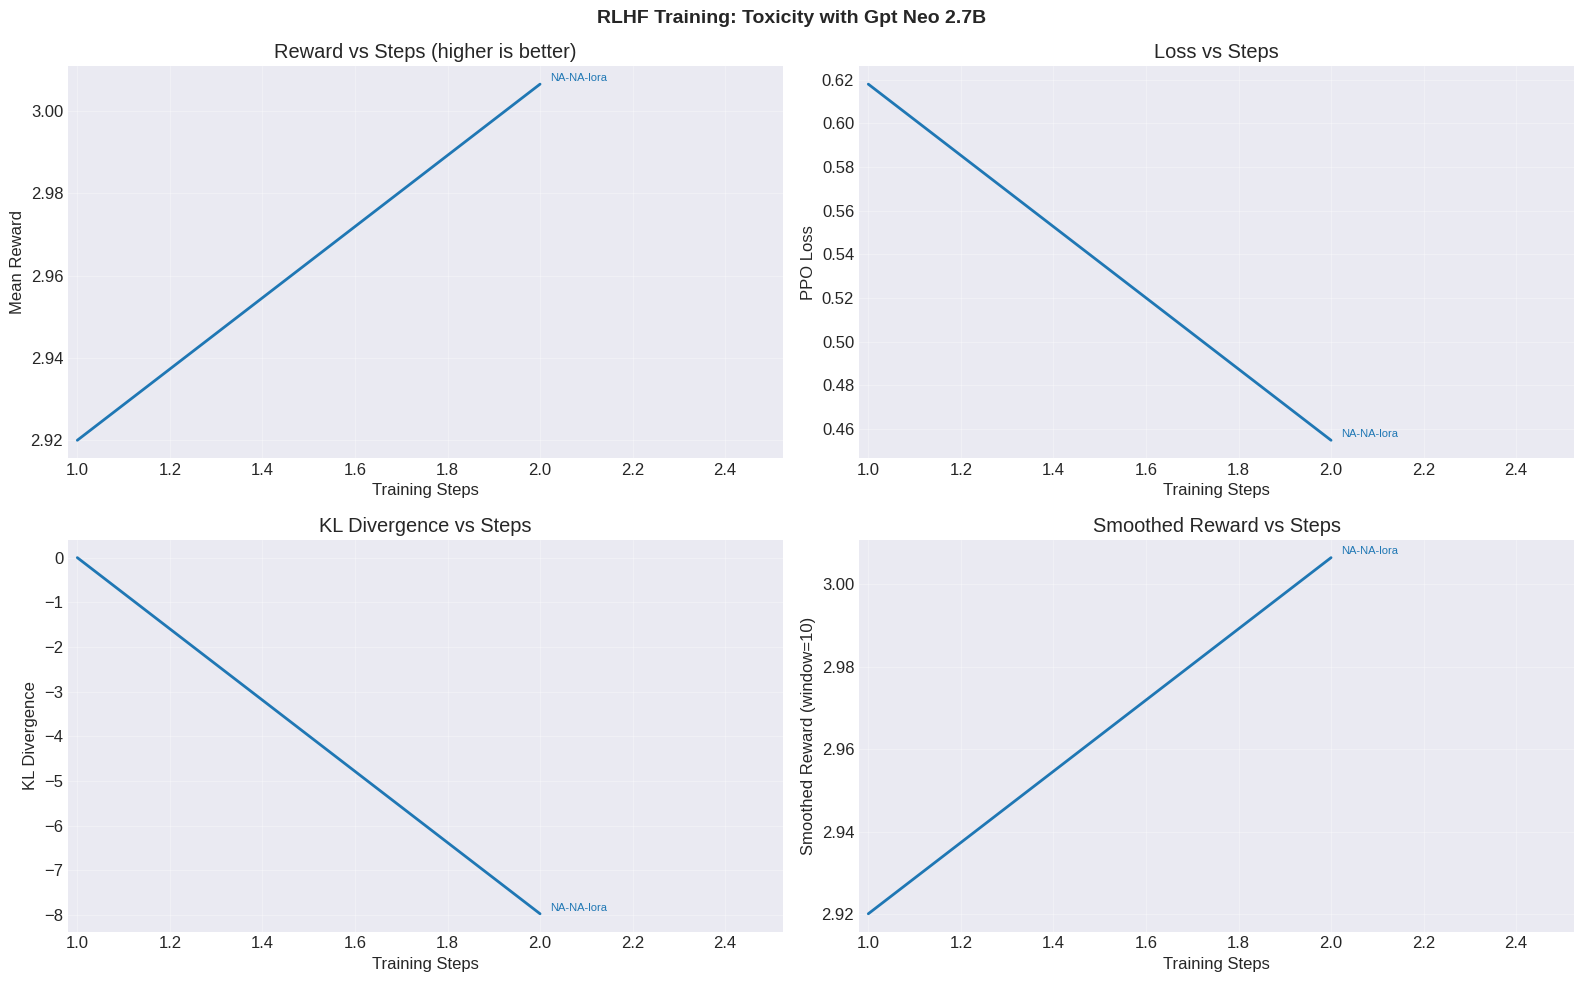

In [134]:
# Create 2x2 plot: Reward and Loss vs Steps

model_name = model.replace('-', ' ').title()
task_name = task.title()
plot_title = f"RLHF Training: {task_name} with {model_name}"

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(plot_title, fontsize=14, fontweight='bold', y=0.98)


def plot_metric(ax, x_data, y_data, x_label, y_label, title, method_names, data_dict):
    """Helper to plot a metric with consistent styling."""
    texts = []
    for name in method_names:
        if name not in data_dict:
            continue
        data = data_dict[name]
        x = x_data(data)
        y = y_data(data)
        if x is None or len(x) == 0:
            continue
        line, = ax.plot(x, y, linewidth=2, label=name)
        texts.append(ax.text(x[-1], y[-1], name, fontsize=8, color=line.get_color()))

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0.02)
    ax.set_xlim(right=ax.get_xlim()[1] * 1.25)
    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))


# Reward vs Steps
plot_metric(
    axes[0, 0],
    x_data=lambda d: d['steps'],
    y_data=lambda d: d['reward_mean'],
    x_label='Training Steps',
    y_label='Mean Reward',
    title='Reward vs Steps (higher is better)',
    method_names=results.keys(),
    data_dict=results
)

# Loss vs Steps
plot_metric(
    axes[0, 1],
    x_data=lambda d: d['steps'],
    y_data=lambda d: d['loss'],
    x_label='Training Steps',
    y_label='PPO Loss',
    title='Loss vs Steps',
    method_names=results.keys(),
    data_dict=results
)

# KL Divergence vs Steps
plot_metric(
    axes[1, 0],
    x_data=lambda d: d['steps'],
    y_data=lambda d: d['kl'],
    x_label='Training Steps',
    y_label='KL Divergence',
    title='KL Divergence vs Steps',
    method_names=results.keys(),
    data_dict=results
)

# Smoothed Reward (moving average)
def smooth(y, window=10):
    if len(y) < window:
        return y
    return np.convolve(y, np.ones(window)/window, mode='valid')

texts = []
for name in results.keys():
    data = results[name]
    x = data['steps']
    y = smooth(data['reward_mean'])
    if len(y) == 0:
        continue
    x = x[:len(y)]  # Adjust x to match smoothed y length
    line, = axes[1, 1].plot(x, y, linewidth=2, label=name)
    texts.append(axes[1, 1].text(x[-1], y[-1], name, fontsize=8, color=line.get_color()))

axes[1, 1].set_xlabel('Training Steps')
axes[1, 1].set_ylabel('Smoothed Reward (window=10)')
axes[1, 1].set_title('Smoothed Reward vs Steps')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].margins(x=0.02)
axes[1, 1].set_xlim(right=axes[1, 1].get_xlim()[1] * 1.25)
if texts:
    adjust_text(texts, ax=axes[1, 1], arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.tight_layout()
plt.show()

## Compare Final Performance

In [135]:
# Print final results
print(f"\n{'='*80}")
print(f"Final Training Results: {task}")
print(f"{'='*80}")
print(f"{'Method':<30} {'Final Reward':<15} {'Final Loss':<15} {'Final KL':<15}")
print("-" * 80)

# Sort by final reward (higher is better for toxicity)
sorted_results = sorted(
    results.items(),
    key=lambda x: x[1]['reward_mean'][-1] if len(x[1]['reward_mean']) > 0 else float('-inf'),
    reverse=True
)

for name, data in sorted_results:
    if len(data['reward_mean']) == 0:
        continue
    final_reward = data['reward_mean'][-1]
    final_loss = data['loss'][-1]
    final_kl = data['kl'][-1]
    print(f"{name:<30} {final_reward:<15.4f} {final_loss:<15.4f} {final_kl:<15.4f}")

print("=" * 80)


Final Training Results: toxicity
Method                         Final Reward    Final Loss      Final KL       
--------------------------------------------------------------------------------
NA-NA-lora                     3.0065          0.4547          -7.9751        


## Task-Specific Evaluation Results

Load and display task-specific metrics:
- **Toxicity**: Mean toxicity score, % toxic responses
- **IMDB**: Sentiment accuracy

In [136]:
# Task-specific evaluation metrics configuration
TASK_METRICS = {
    'toxicity': {
        'result_file': 'eval_results.json',
        'metrics': ['mean_toxicity', 'pct_toxic', 'mean_reward'],
        'display_names': ['Mean Toxicity', '% Toxic', 'Mean Reward'],
        'primary_metric': 'mean_toxicity',  # Lower is better
        'higher_is_better': False,
        'format': lambda x: f"{x:.4f}" if x is not None else 'N/A'
    },
    'imdb': {
        'result_file': 'eval_results.json',
        'metrics': ['accuracy', 'mean_reward'],
        'display_names': ['Accuracy', 'Mean Reward'],
        'primary_metric': 'accuracy',
        'higher_is_better': True,
        'format': lambda x: f"{x*100:.1f}%" if x is not None else 'N/A'
    }
}


def load_eval_results():
    """Load task-specific evaluation results for all methods."""
    eval_results = {}
    for method_name in filtered_methods.keys():
        exp_dir = build_experiment_path(method_name, default_config)
        if exp_dir is None:
            continue

        if task in TASK_METRICS:
            result_file = TASK_METRICS[task]['result_file']
            result_path = f"{exp_dir}/{result_file}"
            if Path(result_path).exists():
                with open(result_path, 'r') as f:
                    eval_results[method_name] = json.load(f)
    return eval_results


# Load evaluation results
eval_results = load_eval_results()

if eval_results and task in TASK_METRICS:
    config = TASK_METRICS[task]
    metrics = config['metrics']
    display_names = config['display_names']
    fmt = config['format']
    primary = config['primary_metric']
    reverse = config['higher_is_better']

    # Sort by primary metric
    sorted_methods = sorted(
        eval_results.items(),
        key=lambda x: x[1].get(primary, 0) or 0,
        reverse=reverse
    )

    # Print results table
    print(f"\n{'='*80}")
    print(f"Evaluation Results: {task.upper()}")
    print(f"{'='*80}")

    header = f"{'Method':<30}"
    for name in display_names:
        header += f" {name:>15}"
    print(header)
    print("-" * 80)

    for method_name, data in sorted_methods:
        row = f"{method_name:<30}"
        for metric in metrics:
            value = data.get(metric)
            row += f" {fmt(value):>15}"
        print(row)

    print("=" * 80)
    print(f"Loaded {len(eval_results)}/{len(filtered_methods)} evaluation results")
else:
    print(f"\nNo evaluation results found for {task}")
    print("Run: python -m RLHF.eval.eval --models_dir <path> --task", task)


No evaluation results found for toxicity
Run: python -m RLHF.eval.eval --models_dir <path> --task toxicity


## Improvement over Baseline

In [137]:
# Compare improvement over NA-NA baseline
if results:
    baseline_name = 'NA-NA-full'

    if baseline_name in results and len(results[baseline_name]['reward_mean']) > 0:
        baseline_reward = results[baseline_name]['reward_mean'][-1]

        print(f"\n{'='*60}")
        print(f"Reward Improvement over Baseline ({baseline_name})")
        print(f"{'='*60}")
        print(f"{'Method':<30} {'Final Reward':<15} {'Improvement':<15}")
        print("-" * 60)

        for name, data in sorted_results:
            if len(data['reward_mean']) == 0:
                continue
            final_reward = data['reward_mean'][-1]
            improvement = final_reward - baseline_reward
            sign = '+' if improvement >= 0 else ''
            print(f"{name:<30} {final_reward:<15.4f} {sign}{improvement:<14.4f}")

        print("=" * 60)
    else:
        print(f"Baseline {baseline_name} not found")

Baseline NA-NA-full not found
